# Sesión de clase 07 · Ejercicio 2: modelo preentrenado frente a zero-shot

Comparamos dos formas de clasificar las **110 reseñas de entrega**
(`data/resenas_entrega.csv`) **sin entrenar nada** con datos de la tienda:

- **Enfoque A — modelo preentrenado de reseñas:**
  `nlptown/bert-base-multilingual-uncased-sentiment` predice de 1 a 5
  estrellas. Ya fue ajustado con reseñas de productos en seis idiomas.
- **Enfoque B — zero-shot con embeddings y ChromaDB:** escribimos tres
  frases prototipo por clase, las guardamos en una colección de Chroma y
  cada reseña va a la clase de su prototipo más parecido (coseno más alto).

**Referencia:** las estrellas del cliente (1–5) y su versión en 3 clases.

**Métricas:**
- **Macro-F1:** promedio del F1 de las 3 clases, cada una con igual peso.
- **κ de Cohen:** cuánto supera el modelo a responder al azar (0 = azar,
  1 = perfecto).
- **MAE:** en promedio, ¿por cuántas estrellas se equivoca el modelo? (solo
  el enfoque A predice estrellas).

In [1]:
import chromadb
import matplotlib.pyplot as plt
import pandas as pd
from chromadb.utils import embedding_functions
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             cohen_kappa_score, f1_score)
from transformers import pipeline

pd.set_option("display.max_colwidth", 120)
CLASES = ["neg", "neu", "pos"]
a3 = lambda s: "neg" if s <= 2 else ("neu" if s == 3 else "pos")

## 1. Referencia

In [2]:
r = pd.read_csv("../data/resenas_entrega.csv")
r["y"] = r["calificacion"].map(a3)

print(r.shape)
pd.DataFrame({"reseñas": r["calificacion"].value_counts().sort_index()})

(110, 8)


,reseñas
calificacion,
1,10
2,15
3,21
4,29
5,35


In [3]:
r["y"].value_counts()[CLASES]

y
neg    25
neu    21
pos    64
Name: count, dtype: int64

## 2. Enfoque A: modelo de reseñas (1 a 5 estrellas)

La etiqueta del modelo es un texto como `"4 stars"`: su primer carácter es
el número de estrellas.

In [4]:
clf = pipeline("text-classification",
               model="nlptown/bert-base-multilingual-uncased-sentiment")
pred = clf(r["texto"].tolist(), batch_size=16, truncation=True)
r["est_pred"] = [int(p["label"][0]) for p in pred]
r["pred_a"] = r["est_pred"].map(a3)

mae = (r["est_pred"] - r["calificacion"]).abs().mean()
print(f"MAE      = {mae:.2f} estrellas")
print(f"macro-F1 = {f1_score(r['y'], r['pred_a'], average='macro'):.3f}")
print(f"kappa    = {cohen_kappa_score(r['y'], r['pred_a']):.3f}")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

MAE      = 0.79 estrellas
macro-F1 = 0.693
kappa    = 0.554


Estrellas reales (filas) frente a estrellas predichas (columnas): los
aciertos exactos están en la diagonal; los errores de una estrella, junto a
ella.

In [5]:
pd.crosstab(r["calificacion"], r["est_pred"],
            rownames=["real"], colnames=["predicho"])

predicho,1,2,3,4,5
real,,,,,
1,9,0,0,1,0
2,7,3,3,2,0
3,3,1,12,3,2
4,4,1,1,12,11
5,4,2,2,4,23


## 3. Enfoque B: zero-shot con embeddings y ChromaDB

Tres frases prototipo por clase. Cada frase se guarda con su clase como
**metadato**; con `n_results=1` Chroma devuelve el prototipo más cercano a
cada reseña y su clase es la predicción.

Usamos el mismo modelo de embeddings de la sesión anterior:
`paraphrase-multilingual-MiniLM-L12-v2`.

In [6]:
PROTOTIPOS = {
    "pos": ["El pedido llegó rápido y en perfecto estado.",
            "Estoy muy satisfecho con la compra y con la entrega.",
            "Excelente servicio, todo llegó completo y bien empacado."],
    "neu": ["La entrega fue normal, llegó en la fecha indicada.",
            "El producto llegó bien aunque hubo un detalle menor.",
            "Cumple con lo esperado, ni bueno ni malo."],
    "neg": ["El pedido llegó con retraso y tuve que reclamar.",
            "El producto llegó dañado o incompleto.",
            "Muy mala experiencia con la entrega, estoy insatisfecho."],
}

ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="paraphrase-multilingual-MiniLM-L12-v2")

cliente = chromadb.Client()
col_prototipos = cliente.get_or_create_collection(
    name="prototipos_sentimiento",
    embedding_function=ef,
    metadata={"hnsw:space": "cosine"},
)

ids, docs, metas = [], [], []
for clase, frases in PROTOTIPOS.items():
    for i, frase in enumerate(frases):
        ids.append(f"{clase}_{i}")
        docs.append(frase)
        metas.append({"clase": clase})
col_prototipos.upsert(ids=ids, documents=docs, metadatas=metas)
col_prototipos.count()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

9

In [7]:
res = col_prototipos.query(query_texts=r["texto"].tolist(), n_results=1)

r["pred_b"] = [m[0]["clase"] for m in res["metadatas"]]
r["prototipo"] = [d[0] for d in res["documents"]]
r["similitud"] = [round(1 - d[0], 3) for d in res["distances"]]

print(f"macro-F1 = {f1_score(r['y'], r['pred_b'], average='macro'):.3f}")
print(f"kappa    = {cohen_kappa_score(r['y'], r['pred_b']):.3f}")
r[["calificacion", "pred_b", "similitud", "prototipo", "texto"]].head(6)

macro-F1 = 0.483
kappa    = 0.284


,calificacion,pred_b,similitud,prototipo,texto
0,1,neg,0.472,El pedido llegó con retraso y tuve que reclamar.,"Recibi el pedido incompleto, faltaba el cable de carga original del OnePlus 12 dentro de la caja. Tuve que esperar u..."
1,3,pos,0.380,El pedido llegó rápido y en perfecto estado.,"El segundo cargador Belkin llego sin contratiempos, en el tiempo estimado y correctamente empacado."
2,5,pos,0.398,Estoy muy satisfecho con la compra y con la entrega.,La segunda Switch Lite que regale llego perfecta y justo a tiempo para el cumpleanos que la necesitaba. Toda la expe...
3,5,neu,0.337,El producto llegó bien aunque hubo un detalle menor.,"El segundo television TCL llego perfecto, bien empacado y sin ningun dano, muy distinto a la primera experiencia neg..."
4,4,neu,0.483,"La entrega fue normal, llegó en la fecha indicada.",Me confirmaron por correo la garantia de un ano del cable Anker sin ningun problema.
5,5,pos,0.358,El pedido llegó rápido y en perfecto estado.,"Los audifonos Bose se emparejaron al instante con mi telefono, cero complicaciones."


## 4. Comparar

In [8]:
def metricas(y, pred):
    return {"macro-F1": f1_score(y, pred, average="macro"),
            "κ de Cohen": cohen_kappa_score(y, pred)}

comparacion = pd.DataFrame({
    "A · nlptown (1–5★)": {**metricas(r["y"], r["pred_a"]), "MAE (estrellas)": mae},
    "B · zero-shot ChromaDB": {**metricas(r["y"], r["pred_b"]), "MAE (estrellas)": None},
}).T.round(3)
comparacion

,macro-F1,κ de Cohen,MAE (estrellas)
A · nlptown (1–5★),0.693,0.554,0.791
B · zero-shot ChromaDB,0.483,0.284,NaN


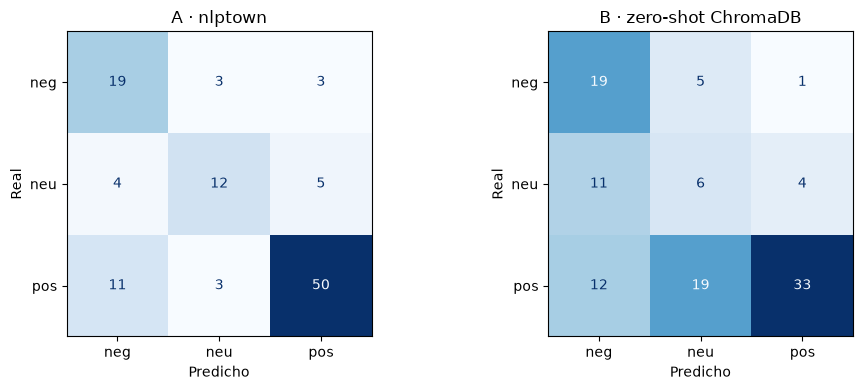

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, titulo in [(axes[0], "pred_a", "A · nlptown"),
                        (axes[1], "pred_b", "B · zero-shot ChromaDB")]:
    ConfusionMatrixDisplay.from_predictions(
        r["y"], r[col], labels=CLASES, ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(titulo)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [10]:
for col, titulo in [("pred_a", "A · nlptown"), ("pred_b", "B · zero-shot ChromaDB")]:
    print(titulo)
    print(classification_report(r["y"], r[col], labels=CLASES, digits=3, zero_division=0))

A · nlptown
              precision    recall  f1-score   support

         neg      0.559     0.760     0.644        25
         neu      0.667     0.571     0.615        21
         pos      0.862     0.781     0.820        64

    accuracy                          0.736       110
   macro avg      0.696     0.704     0.693       110
weighted avg      0.756     0.736     0.741       110

B · zero-shot ChromaDB
              precision    recall  f1-score   support

         neg      0.452     0.760     0.567        25
         neu      0.200     0.286     0.235        21
         pos      0.868     0.516     0.647        64

    accuracy                          0.527       110
   macro avg      0.507     0.520     0.483       110
weighted avg      0.646     0.527     0.550       110



**Lectura:** el zero-shot con prototipos encuentra casi la misma proporción
de negativos que nlptown, pero se hunde en la clase **neutra** y manda
muchas reseñas positivas a neutro o negativo: la similitud coseno mide *de
qué habla* el texto (entrega, retraso, empaque) más que *cómo lo valora*.

### Los 10 desacuerdos más grandes (enfoque A)

Ordenados por la distancia en estrellas entre la predicción y la calificación
del cliente. Antes de culpar al modelo, lean el texto: ¿la estrella del
cliente refleja lo que escribió?

In [11]:
r["error_estrellas"] = (r["est_pred"] - r["calificacion"]).abs()
r.sort_values("error_estrellas", ascending=False).head(10)[
    ["calificacion", "est_pred", "pred_b", "texto"]]

,calificacion,est_pred,pred_b,texto
63,5,1,neu,La instalacion del Sony Bravia estuvo lista en menos de una hora gracias al tecnico.
38,5,1,pos,"La webcam Logitech llego al dia siguiente de realizar el pedido. Todo llego completo, con caja original y sellada."
53,5,1,neg,El Galaxy Watch se sincronizo con mi telefono en segundos apenas lo active.
48,5,1,neg,"Cuando tuve una duda sobre la garantia de la Acer, me respondieron el mismo dia."
15,1,4,neg,"Recibi el pedido con los audifonos SteelSeries de un color distinto al solicitado, sin ninguna indicacion previa del..."
54,4,1,pos,"El cable Anker llego junto con otros productos de mi pedido, todo en un solo envio."
24,4,1,neg,Resolvieron mi consulta sobre el hervidor Xiaomi mediante un video explicativo por correo.
9,4,1,pos,El Amazfit se sincronizo sin problemas con la app apenas lo encendi.
103,5,2,neu,"La Xbox se actualizo sola apenas la conecte a internet, lista para jugar en poco tiempo."
79,4,1,neg,"El hervidor Xiaomi llego completo, solo el manual venia en ingles y no en espanol."


Casi todos son textos **cortos y descriptivos** («se sincronizó en
segundos», «llegó al día siguiente») calificados con 4–5★: no contienen
ninguna palabra de valoración y el modelo, entrenado con reseñas que sí
opinan, no sabe qué hacer con ellos. El caso inverso (1★ predicho como 4★)
es una queja sin ninguna palabra negativa explícita: «llegó de un color
distinto al solicitado».

### ¿Dónde discrepan los dos enfoques?

In [12]:
pd.crosstab(r["pred_a"], r["pred_b"],
            rownames=["A · nlptown"], colnames=["B · zero-shot"])

B · zero-shot,neg,neu,pos
A · nlptown,,,
neg,23,5,6
neu,11,5,2
pos,8,20,30


In [13]:
print(f"κ entre A y B: {cohen_kappa_score(r['pred_a'], r['pred_b']):.3f}")
r[(r["pred_a"] != r["pred_b"]) & (r["pred_a"] != "neu") & (r["pred_b"] != "neu")][
    ["calificacion", "est_pred", "pred_b", "prototipo", "texto"]]

κ entre A y B: 0.279


,calificacion,est_pred,pred_b,prototipo,texto
9,4,1,pos,El pedido llegó rápido y en perfecto estado.,El Amazfit se sincronizo sin problemas con la app apenas lo encendi.
12,4,5,neg,El pedido llegó con retraso y tuve que reclamar.,Me explicaron por chat como registrar la garantia internacional de la Canon Rebel.
13,5,2,pos,Estoy muy satisfecho con la compra y con la entrega.,El Galaxy S24 Ultra ya venia con la mayoria del software actualizado desde fabrica.
15,1,4,neg,El pedido llegó con retraso y tuve que reclamar.,"Recibi el pedido con los audifonos SteelSeries de un color distinto al solicitado, sin ninguna indicacion previa del..."
28,5,5,neg,El producto llegó dañado o incompleto.,El equipo de soporte reemplazo rapido un cable defectuoso de mis audifonos Bose.
31,1,1,pos,El pedido llegó rápido y en perfecto estado.,"El telefono llego usado, con marcas de uso en la pantalla que no correspondian a un equipo nuevo segun la orden de c..."
33,4,4,neg,El producto llegó dañado o incompleto.,El disco WD Blue llego bien protegido contra golpes con plastico de burbuja.
38,5,1,pos,"Excelente servicio, todo llegó completo y bien empacado.","La webcam Logitech llego al dia siguiente de realizar el pedido. Todo llego completo, con caja original y sellada."
44,4,5,neg,El pedido llegó con retraso y tuve que reclamar.,El soporte me ayudo por telefono a resolver un error de conexion del robot aspiradora.
54,4,1,pos,"Excelente servicio, todo llegó completo y bien empacado.","El cable Anker llego junto con otros productos de mi pedido, todo en un solo envio."


## Discusión

- ¿Qué enfoque confunde más la clase **neutra**? Revisen la exhaustividad
  (*recall*) de `neu` en ambos reportes.
- El enfoque B depende por completo de las frases prototipo. Reescriban los
  prototipos neutros (por ejemplo, con frases que mezclen un elogio y una
  queja) y vuelvan a ejecutar: ¿sube el macro-F1?
- El MAE de A mide errores **ordinales**: equivocarse de 4★ a 5★ no es lo
  mismo que de 1★ a 5★. ¿Qué métrica usarían para comparar A con un modelo
  de tres clases?

In [14]:
# Espacio para experimentar: prototipos neutros que mezclan elogio y queja
PROTOTIPOS_V2 = dict(PROTOTIPOS)
PROTOTIPOS_V2["neu"] = ["El producto llegó bien, pero la entrega tardó un poco más.",
                        "Buen producto, aunque el empaque podría mejorar.",
                        "Llegó a tiempo, aunque faltó información del seguimiento."]

col_v2 = cliente.get_or_create_collection(
    name="prototipos_sentimiento_v2", embedding_function=ef,
    metadata={"hnsw:space": "cosine"})
col_v2.upsert(
    ids=[f"{c}_{i}" for c, fs in PROTOTIPOS_V2.items() for i in range(len(fs))],
    documents=[f for fs in PROTOTIPOS_V2.values() for f in fs],
    metadatas=[{"clase": c} for c, fs in PROTOTIPOS_V2.items() for _ in fs])

res_v2 = col_v2.query(query_texts=r["texto"].tolist(), n_results=1)
pred_b_v2 = [m[0]["clase"] for m in res_v2["metadatas"]]
pd.DataFrame({"B · prototipos originales": metricas(r["y"], r["pred_b"]),
              "B · prototipos v2": metricas(r["y"], pred_b_v2)}).T.round(3)

,macro-F1,κ de Cohen
B · prototipos originales,0.483,0.284
B · prototipos v2,0.557,0.364
